# Chapter 11 — Bermudan Swaption Tree Pricing

# 1. Introduction
## Hull-White Tree-Based Backward Induction

This chapter prices Bermudan swaptions using a short-rate tree.

A Bermudan swaption gives the holder the right, but not the obligation, to enter into an interest-rate swap on a set of predetermined exercise dates.

This chapter builds on Chapter 09:

```text
Chapter 09
Hull-White Short-Rate Model
        ↓
Chapter 11
Bermudan Swaption Tree Pricing
```

The chapter implements:

- Bermudan exercise schedule
- underlying swap schedule after exercise
- Hull-White-style short-rate tree
- swap value at each tree node
- backward induction
- exercise decision analysis


## Next Chapter

Chapter 12 will price the same type of Bermudan swaption using Longstaff-Schwartz Monte Carlo:

```text
Chapter 12
Bermudan Swaption LSM Pricing
```

This provides a natural comparison between:

```text
Tree-based dynamic programming
vs
Simulation-based regression
```

---

# 2. Import Libraries and Data

In [2]:
# ============================================================
# Cell 1 — Imports and Paths
# ============================================================

import sys
import os

# Chapter 11 files
sys.path.append("../python")

# Reuse Chapter 09 files
sys.path.append("../../09_hull_white_short_rate_model/python")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import (
    load_curve_data,
    curve_to_dataframe
)

from hull_white_model import (
    HullWhiteModel
)

from bond_pricing import (zero_coupon_bond_price)

from swap_schedule import (
    generate_payment_dates,
    generate_exercise_dates
)

from bermudan_swaption import (
    BermudanSwaption
)

from hull_white_tree import (
    HullWhiteBinomialTree
)

from tree_pricer import (
    BermudanSwaptionTreePricer
)

from plotting import (
    plot_short_rate_tree,
    plot_tree_values,
    plot_exercise_boundary
)

from diagnostics import (
    print_tree_summary,
    print_instrument_summary,
    print_pricing_summary,
    exercise_statistics
)

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# Cell 2 — Load Yield Curve
# ============================================================

curve = load_curve_data(
    "../../09_hull_white_short_rate_model/data/usd_zero_curve.csv"
)

curve_times = np.array([
    0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30
])

curve_df = curve_to_dataframe(
    curve,
    curve_times
)

curve_df

,time,discount_factor,zero_rate
0,0.25,0.995012,0.0200
1,0.50,0.989555,0.0210
2,1.00,0.978240,0.0220
3,2.00,0.953134,0.0240
4,3.00,0.927743,0.0250
5,5.00,0.873716,0.0270
6,7.00,0.819140,0.0285
7,10.00,0.740818,0.0300
8,15.00,0.618783,0.0320
9,20.00,0.516851,0.0330


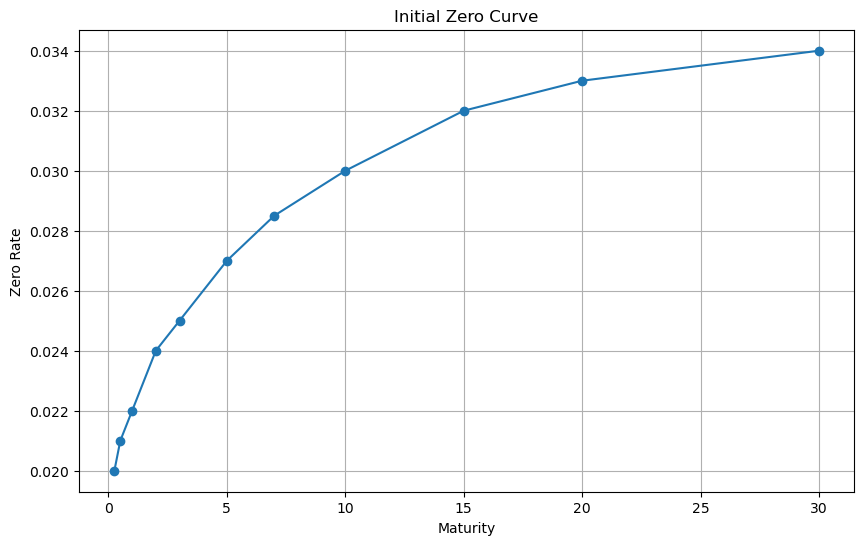

In [4]:
# ============================================================
# Cell 3 — Plot Initial Zero Curve
# ============================================================

plt.figure()

plt.plot(
    curve_df["time"],
    curve_df["zero_rate"],
    marker="o"
)

plt.title("Initial Zero Curve")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.grid()
plt.show()

---
# 3. Bermudan Swaption Definition

In this chapter, the Bermudan swaption is defined using a market-style convention.

At each exercise date:

```text
exercise at time t
        ↓
enter into a swap starting at t
        ↓
swap ends at t + swap_tenor
```

Example:

```text
option_start = 1Y
option_end   = 5Y
swap_tenor   = 5Y
```

Then:

```text
exercise at 1Y → enter 1Y to 6Y swap
exercise at 2Y → enter 2Y to 7Y swap
exercise at 3Y → enter 3Y to 8Y swap
exercise at 4Y → enter 4Y to 9Y swap
exercise at 5Y → enter 5Y to 10Y swap
```

This is more realistic than using one fixed swap schedule for all exercise dates.

In [5]:
# ============================================================
# Generate Exercise and Payment Dates
# ============================================================

exercise_dates = generate_exercise_dates(
    first_exercise=1.0,
    last_exercise=5.0,
    exercise_frequency=1
)

payment_dates_example = generate_payment_dates(
    start=2.0,
    end=7.0,
    payment_frequency=2
)

print("Exercise dates:")
print(exercise_dates)

print("\nExample payment dates for exercising at 2Y into a 5Y swap:")
print(payment_dates_example)

Exercise dates:
[1. 2. 3. 4. 5.]

Example payment dates for exercising at 2Y into a 5Y swap:
[2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7. ]


In [6]:
# ============================================================
# Create Bermudan Swaption
# ============================================================

bermudan = BermudanSwaption(
    notional=1_000_000,
    fixed_rate=0.045,
    option_start=1.0,
    option_end=5.0,
    swap_tenor=5.0,
    payment_frequency=2,
    exercise_frequency=1,
    payer=True
)

print_instrument_summary(
    bermudan
)

Bermudan Swaption Summary
Notional          : 1,000,000.00
Fixed rate        : 0.045000
Payer             : True
Option start      : 1.0
Option end        : 5.0
Swap tenor        : 5.0
Payment frequency : 2
Exercise frequency: 1

Exercise dates:
[1. 2. 3. 4. 5.]

Example payment schedules:
Exercise at 1.00Y -> swap 1.00Y to 6.00Y
[1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6. ]
Exercise at 2.00Y -> swap 2.00Y to 7.00Y
[2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7. ]
Exercise at 3.00Y -> swap 3.00Y to 8.00Y
[3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8. ]
Exercise at 4.00Y -> swap 4.00Y to 9.00Y
[4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5 9. ]
Exercise at 5.00Y -> swap 5.00Y to 10.00Y
[ 5.5  6.   6.5  7.   7.5  8.   8.5  9.   9.5 10. ]


---
# 4. Underlying Swap Value at an Exercise Node

At any exercise date \(t\), the option holder can enter into a swap.

For a payer Bermudan swaption, the holder pays fixed and receives floating.

The underlying payer swap value is:

$$
V_{swap}(t) =
N
A(t)
\left(
S(t)-K
\right)
$$

where:

- \(N\) is notional
- \(K\) is fixed rate
- \(S(t)\) is the forward swap rate at the node
- \(A(t)\) is the fixed-leg annuity

The annuity is:

$$
A(t) =
\sum_i
\Delta_i
P(t,T_i)
$$

and the forward swap rate is:

$$
S(t) =
\frac{
1-P(t,T_N)
}{
A(t)
}
$$

The immediate exercise value is:

$$
\max(V_{swap}(t),0)
$$

In [7]:
# ============================================================
# Create Hull-White Model
# ============================================================

hw_model = HullWhiteModel(
    mean_reversion=0.05,
    volatility=0.01,
    curve=curve
)

r0 = hw_model.instantaneous_forward_rate(
    1e-6
)

print("Initial short-rate proxy:", r0)
print("Theta(2Y):", hw_model.theta(2.0))

Initial short-rate proxy: 0.02000000000000102
Theta(2Y): -0.015468980753120226


In [8]:
# ============================================================
# Swap Value Example at One Exercise Node
# ============================================================

exercise_time = 2.0
short_rate = 0.045

annuity = bermudan.annuity(
    model=hw_model,
    exercise_time=exercise_time,
    short_rate=short_rate
)

swap_rate = bermudan.forward_swap_rate(
    model=hw_model,
    exercise_time=exercise_time,
    short_rate=short_rate
)

swap_value = bermudan.swap_value(
    model=hw_model,
    exercise_time=exercise_time,
    short_rate=short_rate
)

exercise_value = bermudan.exercise_value(
    model=hw_model,
    exercise_time=exercise_time,
    short_rate=short_rate
)

print("Exercise time:", exercise_time)
print("Short rate:", short_rate)
print("Annuity:", annuity)
print("Forward swap rate:", swap_rate)
print("Swap value:", swap_value)
print("Exercise value:", exercise_value)

Exercise time: 2.0
Short rate: 0.045
Annuity: 4.415942821387777
Forward swap rate: 0.04705431317011489
Swap value: 9071.729496451213
Exercise value: 9071.729496451213


---
# 5. Hull-White Binomial Tree

This chapter uses an educational recombining binomial approximation to the Hull-White short-rate model.

The Hull-White short-rate process is:

$$
dr_t =
\left(
\theta(t)-a r_t
\right)dt
+
\sigma dW_t
$$

In a direct Euler simulation, the short rate would evolve as:

$$
r_{t+\Delta t} =
r_t
+
\left(
\theta(t)-a r_t
\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
$$

However, a recombining tree separates the drift and diffusion effects:

```text
node spacing → local variance
transition probabilities → local drift
```

The tree node spacing is:

$$
\Delta r =
\sigma\sqrt{\Delta t}
$$

This $\Delta r$ is not the same as $dr_t$ in the stochastic differential equation.

It is only the distance between adjacent short-rate nodes in the tree.

---

# 6. Meaning of Step and Node

The tree node rate is approximated as:

$$
r(i,j)
=
r_0
+
(2j-i)\Delta r
$$

where:

- \(i\) is the time step
- \(j\) is the node index inside that time step

In the code:

```python
step = i
node = j
```

At step \(i\), there are \(i+1\) nodes.

For example:

```text
step 0:

    j=0
    r(0,0) = r0

step 1:

    j=0 → r0 - Δr
    j=1 → r0 + Δr

step 2:

    j=0 → r0 - 2Δr
    j=1 → r0
    j=2 → r0 + 2Δr

step 3:

    j=0 → r0 - 3Δr
    j=1 → r0 - Δr
    j=2 → r0 + Δr
    j=3 → r0 + 3Δr
```

The term \(2j-i\) makes the tree symmetric around the initial short rate.

---

# 7. Why Node Spacing Is Only σ√Δt

A common confusion is to ask why the tree uses:

$$
\Delta =
\sigma\sqrt{\Delta t}
$$

instead of:

$$
\left(
\theta(t)-ar_t
\right)\Delta t
+
\sigma\sqrt{\Delta t}
$$

The reason is that a recombining tree must keep a fixed grid structure.

The node spacing controls local variance:

$$
Var(\Delta r)=
\sigma^2\Delta t
$$

The drift is introduced separately through transition probabilities.

At a node, the short-rate drift is:

$$
\mu(t,r)=
\theta(t)-ar
$$

The expected tree move is:

$$
E[\Delta r]=p(+\Delta r)+(1-p)(-\Delta r)=
(2p-1)\Delta r
$$

To match the Hull-White drift:

$$
(2p-1)\Delta r=
\mu(t,r)\Delta t
$$

Therefore:

$$
p=
\frac12
+
\frac{
\mu(t,r)\Delta t
}{
2\Delta r
}
$$

So the implementation uses:

```text
node spacing = volatility effect
transition probability = drift effect
```

This keeps the tree recombining.

---

# *** Important Modelling Note

This is not a production-grade Hull-White tree.

It is an educational binomial approximation.

Production Hull-White Bermudan pricing usually uses:

- calibrated trinomial trees
- state-price calibration
- level shifts at each time step
- finite-difference methods
- or Monte Carlo with regression

The current implementation is designed to make the early-exercise logic transparent before Chapter 12 introduces LSM Monte Carlo pricing.

---

# 8. Build Hull-White Tree

In [10]:
# ============================================================
# Cell 8 — Build Hull-White Tree
# ============================================================

tree = HullWhiteBinomialTree(
    model=hw_model,
    maturity=5.0,
    n_steps=40,
    r0=r0
)

print_tree_summary(
    tree
)

Hull-White Tree Summary
Maturity        : 5.0
Number of steps : 40
dt              : 0.125000
dr              : 0.003536
Initial rate    : 0.020000

Final rate range:
min = -0.121421
max = 0.161421


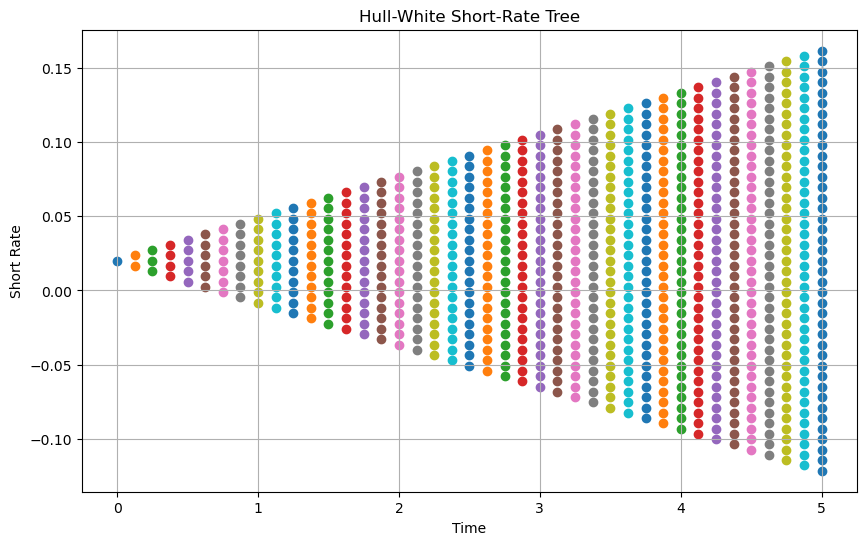

In [11]:
# ============================================================
# Plot Short-Rate Tree
# ============================================================

plot_short_rate_tree(
    tree
)

In [12]:
# ============================================================
# Inspect First Few Tree Levels
# ============================================================

for step in range(5):

    print(f"Step {step}, time={tree.times[step]:.3f}")
    print(tree.rates[step])
    print()

Step 0, time=0.000
[0.02]

Step 1, time=0.125
[0.01646447 0.02353553]

Step 2, time=0.250
[0.01292893 0.02       0.02707107]

Step 3, time=0.375
[0.0093934  0.01646447 0.02353553 0.0306066 ]

Step 4, time=0.500
[0.00585786 0.01292893 0.02       0.02707107 0.03414214]



---
# 9. Backward Induction - Pricing Bermudan swaption

The Bermudan swaption is priced by backward induction.

At each node:

```text
Continuation value
=
discounted expected value of future option values
```

If the node is an exercise date:

```text
Node value
=
max(exercise value, continuation value)
```

Otherwise:

```text
Node value
=
continuation value
```

Mathematically:

$$
V(t,r) =
\max
\left(
E(t,r),
C(t,r)
\right)
$$

at exercise dates, where:

- $E(t,r)$ is immediate exercise value
- $C(t,r)$ is continuation value

At non-exercise dates:

$$
V(t,r) =
C(t,r)
$$

In [13]:
# ============================================================
# Price Bermudan Swaption
# ============================================================

pricer = BermudanSwaptionTreePricer(
    tree=tree,
    bermudan_swaption=bermudan
)

price = pricer.price()

print_pricing_summary(
    price
)

Pricing Result
Bermudan swaption price: 11,489.246147


In [14]:
# ============================================================
# Extract Value and Exercise Trees
# ============================================================

value_tree = pricer.get_value_tree()

exercise_tree = pricer.get_exercise_tree()

print("Root value:", value_tree[0][0])

Root value: 11489.246146786885


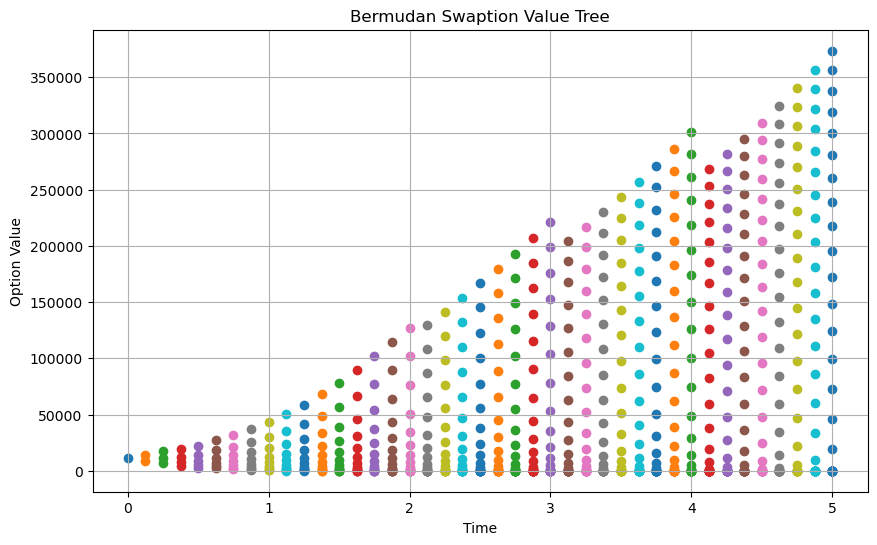

In [15]:
# ============================================================
# Plot Value Tree
# ============================================================

plot_tree_values(
    tree,
    value_tree,
    title="Bermudan Swaption Value Tree"
)

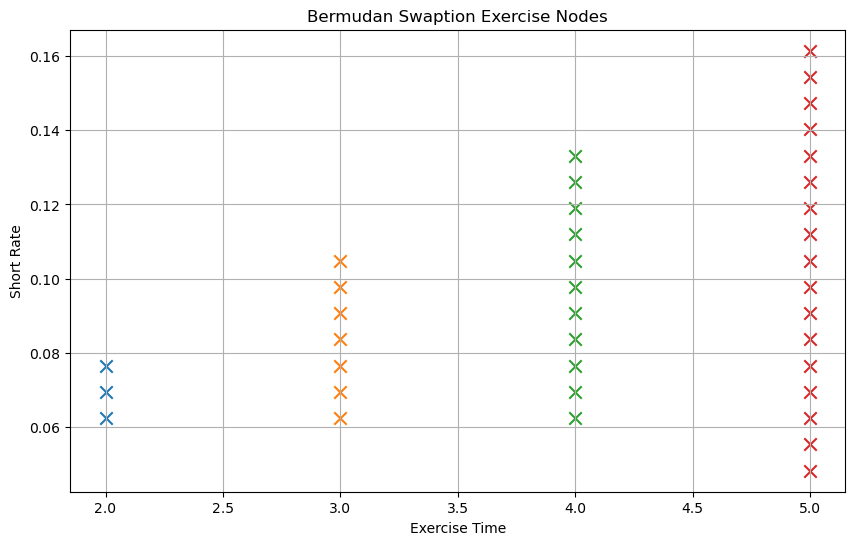

In [16]:
# ============================================================
# Plot Exercise Nodes
# ============================================================

plot_exercise_boundary(
    tree,
    exercise_tree
)

---

# 10. Exercise Statistics

The exercise tree records where immediate exercise is optimal.

A node is marked as exercise when:

$$
E(t,r)
>
C(t,r)
$$

That is, the value of entering the swap immediately exceeds the continuation value of keeping the option alive.

In [17]:
# ============================================================
# Exercise Statistics
# ============================================================

exercise_df = exercise_statistics(
    tree,
    exercise_tree
)

exercise_df[
    exercise_df["exercise_nodes"] > 0
]

,time,exercise_nodes,total_nodes,exercise_ratio
16,2.0,3,17,0.176471
24,3.0,7,25,0.280000
32,4.0,11,33,0.333333
40,5.0,17,41,0.414634


---
# 10. Pricing Sensitivity to Fixed Rate

A payer Bermudan swaption becomes more valuable when the fixed strike is lower.

We test several fixed rates and reprice the Bermudan swaption.

In [18]:
# ============================================================
# Fixed Rate Sensitivity
# ============================================================

fixed_rates = [
    0.035,
    0.040,
    0.045,
    0.050,
    0.055
]

rows = []

for K in fixed_rates:

    instrument = BermudanSwaption(
        notional=1_000_000,
        fixed_rate=K,
        option_start=1.0,
        option_end=5.0,
        swap_tenor=5.0,
        payment_frequency=2,
        exercise_frequency=1,
        payer=True
    )

    pricer_K = BermudanSwaptionTreePricer(
        tree=tree,
        bermudan_swaption=instrument
    )

    price_K = pricer_K.price()

    rows.append(
        {
            "fixed_rate": K,
            "price": price_K
        }
    )

fixed_rate_df = pd.DataFrame(rows)

fixed_rate_df

,fixed_rate,price
0,0.035,26449.277760
1,0.040,18017.777645
2,0.045,11489.246147
3,0.050,6875.673941
4,0.055,3952.895072


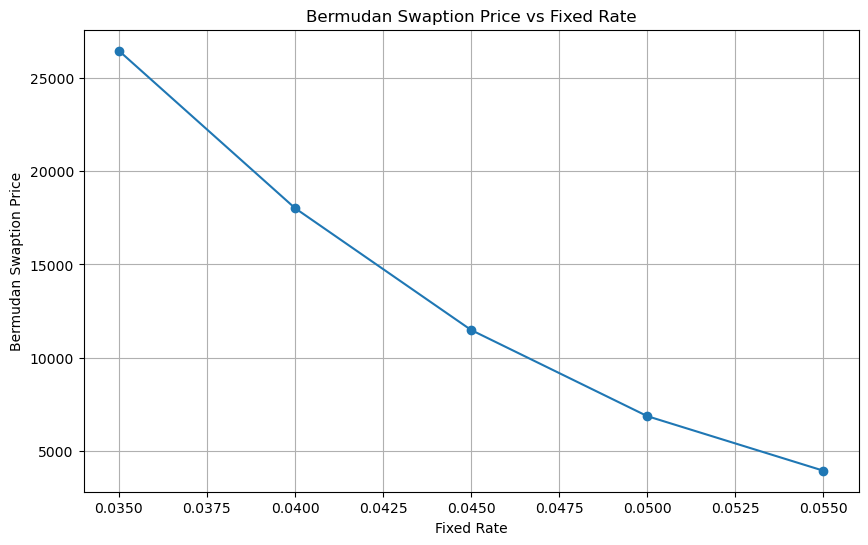

In [19]:
# ============================================================
# Plot Fixed Rate Sensitivity
# ============================================================

plt.figure()

plt.plot(
    fixed_rate_df["fixed_rate"],
    fixed_rate_df["price"],
    marker="o"
)

plt.title("Bermudan Swaption Price vs Fixed Rate")
plt.xlabel("Fixed Rate")
plt.ylabel("Bermudan Swaption Price")
plt.grid()
plt.show()

---
# 12. Pricing Sensitivity to Short-Rate Volatility

Higher short-rate volatility generally increases the value of an option because optionality becomes more valuable when uncertainty is larger.

We test several Hull-White volatility assumptions.

In [21]:
# ============================================================
# Cell 18 — Volatility Sensitivity
# ============================================================

volatilities = [
    0.005,
    0.010,
    0.015,
    0.020
]

rows = []

for sigma in volatilities:

    model_sigma = HullWhiteModel(
        mean_reversion=0.05,
        volatility=sigma,
        curve=curve
    )

    r0_sigma = model_sigma.instantaneous_forward_rate(
        1e-6
    )

    tree_sigma = HullWhiteBinomialTree(
        model=model_sigma,
        maturity=5.0,
        n_steps=40,
        r0=r0_sigma
    )

    pricer_sigma = BermudanSwaptionTreePricer(
        tree=tree_sigma,
        bermudan_swaption=bermudan
    )

    price_sigma = pricer_sigma.price()

    rows.append(
        {
            "sigma": sigma,
            "price": price_sigma
        }
    )

vol_df = pd.DataFrame(rows)

vol_df

,sigma,price
0,0.005,1473.123542
1,0.010,11489.246147
2,0.015,25174.759408
3,0.020,41139.145555


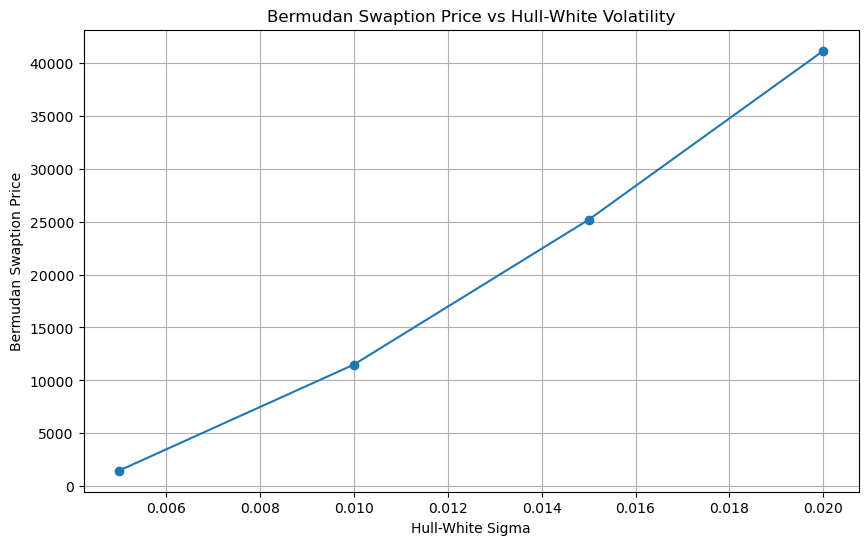

In [22]:
# ============================================================
# Plot Volatility Sensitivity
# ============================================================

plt.figure()

plt.plot(
    vol_df["sigma"],
    vol_df["price"],
    marker="o"
)

plt.title("Bermudan Swaption Price vs Hull-White Volatility")
plt.xlabel("Hull-White Sigma")
plt.ylabel("Bermudan Swaption Price")
plt.grid()
plt.show()

---
# 13. Tree Resolution Sensitivity

Tree pricing can be sensitive to time-step resolution.

A more refined tree usually improves accuracy, but it also increases computational cost.

We test several values of:

```text
n_steps
```

In [24]:
# ============================================================
# Tree Resolution Sensitivity
# ============================================================

step_values = [
    20,
    40,
    80,
    120
]

rows = []

for n in step_values:

    tree_n = HullWhiteBinomialTree(
        model=hw_model,
        maturity=5.0,
        n_steps=n,
        r0=r0
    )

    pricer_n = BermudanSwaptionTreePricer(
        tree=tree_n,
        bermudan_swaption=bermudan
    )

    price_n = pricer_n.price()

    rows.append(
        {
            "n_steps": n,
            "price": price_n
        }
    )

resolution_df = pd.DataFrame(rows)

resolution_df

,n_steps,price
0,20,9171.337428
1,40,11489.246147
2,80,12704.518629
3,120,11452.391442


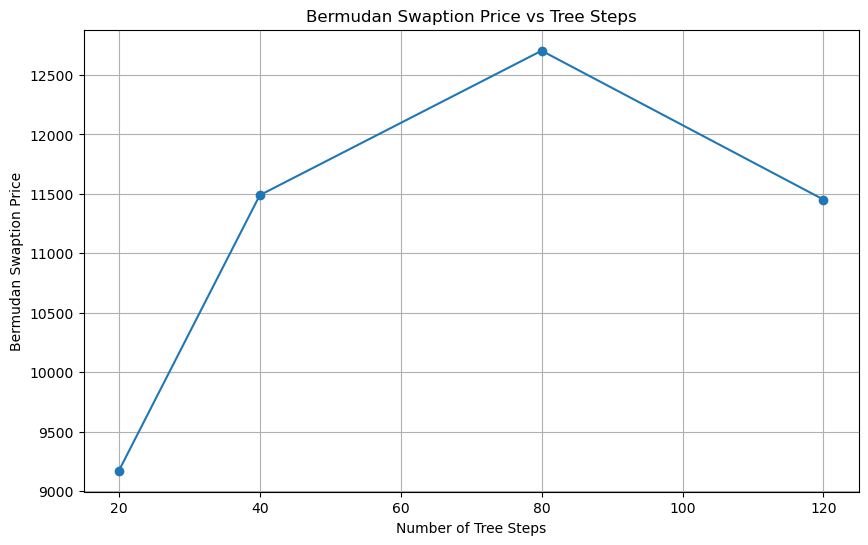

In [25]:
# ============================================================
# Plot Tree Resolution Sensitivity
# ============================================================

plt.figure()

plt.plot(
    resolution_df["n_steps"],
    resolution_df["price"],
    marker="o"
)

plt.title("Bermudan Swaption Price vs Tree Steps")
plt.xlabel("Number of Tree Steps")
plt.ylabel("Bermudan Swaption Price")
plt.grid()
plt.show()

---
# 14. Interpretation

The Bermudan swaption value reflects two components:

```text
European-style swaption value
        +
early exercise value
```

The tree framework is useful because it evaluates the exercise decision recursively.

At each exercise date, the holder compares:

```text
exercise now
vs
continue holding the option
```

This is exactly why backward induction is natural for Bermudan options.

---

# *** Limitations of This Educational Tree

This chapter intentionally uses a simplified binomial short-rate tree.

Important limitations:

1. The tree is not strictly calibrated to the initial discount curve at every time step.
2. Transition probabilities are clipped for numerical stability.
3. The tree is binomial, whereas production Hull-White implementations usually use trinomial trees.
4. Node spacing is symmetric and fixed by \(\sigma\sqrt{\Delta t}\).
5. The model is designed for clarity rather than production accuracy.

These limitations are acceptable for learning the core Bermudan pricing logic.

The next chapter will use Longstaff-Schwartz Monte Carlo, which is more flexible and closer to how high-dimensional early-exercise problems are often solved.

---
# 15. Chapter Summary

In this chapter we implemented:

- a market-style Bermudan swaption definition
- dynamic swap schedules after exercise
- a recombining binomial short-rate tree
- Hull-White drift-adjusted transition probabilities
- backward induction
- exercise decision tracking
- sensitivity analysis for strike, volatility, and tree resolution


## Key Lessons

1. Bermudan swaptions require early-exercise logic.
2. Tree pricing works naturally through backward induction.
3. Node spacing controls local variance.
4. Transition probabilities incorporate drift.
5. The exercise boundary shows where immediate exercise is optimal.
6. A production Hull-White tree is more sophisticated than this educational binomial approximation.


## Next Chapter

### Chapter 12: Bermudan Swaption LSM Pricing

The next chapter prices Bermudan swaptions using Longstaff-Schwartz Monte Carlo.

This allows us to compare:

```text
Tree-based backward induction
vs
Regression-based Monte Carlo
```